## Import Libraries

In [1]:
from importlib.util import find_spec
from pathlib import Path

import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

DATA_DIR = Path("project")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

CHART_CONFIG = {
    "displaylogo": False,
    "responsive": True,
}

In [2]:
from IPython.display import display
from sklearn.metrics import r2_score, mean_absolute_error
from math import exp
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Data Collection-Load The Dataset

In [3]:
population=pd.read_csv("state wise pop.csv")
display(population.head(10))
print("Shape of the Dataset:",population.shape)

,States/Uts,population(1901),population(1951),population(2011),population(2023),population(2024),Male(literacy rate),Female (literacy rate)Average (literacy rate),average (literacy rate),Area (sq. km),GDP,per capita in,sex ratio (number of female per male),Hindu,Muslim,Christian,Sikhs,Buddhist,Others,Majority
0,Andaman and Nicobar Islands,24649,30971,380581,403000,404000,90.11,81.84,86.27,8249,0.89,229000.0,1045,0.6945,0.0852,0.2128,0.0034,0.0009,0.0032,Hindu
1,Andhra Pradesh,13071874,20216637,49386799,53217000,53402000,73.40,59.50,66.40,162970,14.50,219518.0,963,0.9087,0.0733,0.0138,0.0002,0.0001,0.0039,Hindu
2,Arunachal Pradesh,-,-,1383727,1565000,1580000,73.69,59.57,66.95,83743,0.38,256410.0,997,0.2904,0.0195,0.3026,0.0024,0.1177,0.2674,Christian
3,Assam,3289680,8028856,31205576,35824000,36159000,90.10,81.20,85.90,78438,5.67,118504.0,1012,0.6147,0.3422,0.0374,0.0007,0.0018,0.0032,Hindu
4,Bihar,27311865,29085017,104099452,127368000,129205000,79.70,60.50,70.90,94163,8.59,54000.0,1090,0.8269,0.1687,0.0012,0.0002,0.0002,0.0028,Hindu
5,Chandigarh,21967,24261,1055450,1235000,1247000,90.54,81.38,86.43,114,0.49,333000.0,917,0.8078,0.0487,0.0011,0.1311,NaN,0.0113,Hindu
6,Chhattisgarh,4181554,7456706,25545198,30294000,30638000,85.40,68.70,77.30,135192,5.09,152348.0,1015,0.9325,0.0202,0.0192,0.0027,0.0028,0.0226,Hindu
7,Dadra & Nagar Haveli and Daman & Diu,56285,90143,586956,1293000,1387000,89.50,76.20,80.50,603,NaN,NaN,827,0.9393,0.0376,0.0149,0.0006,0.0018,0.0058,Hindu
8,Delhi,405819,1744072,16787941,21490000,21884000,93.70,82.40,88.70,1483,10.40,444768.0,913,0.8168,0.1286,0.0087,0.0340,0.0011,0.0108,Hindu
9,Goa,475513,547448,1458545,1577000,1585000,92.81,81.84,87.40,3702,1.00,527146.0,1027,0.6608,0.0833,0.2510,0.0010,0.0008,0.0031,Hindu


Shape of the Dataset: (35, 20)


## Data Processing-Analyse The Data

In [4]:
population.columns.tolist()

['States/Uts',
 'population(1901)',
 'population(1951)',
 'population(2011)',
 'population(2023)',
 'population(2024)',
 'Male(literacy rate)',
 'Female (literacy rate)Average (literacy rate)',
 'average (literacy rate)',
 'Area (sq. km)',
 'GDP',
 'per capita in',
 'sex ratio (number of female per male)',
 'Hindu',
 'Muslim',
 'Christian',
 'Sikhs',
 'Buddhist',
 'Others',
 'Majority']

In [5]:
pop=population.copy()

In [6]:
pop.head(5)

,States/Uts,population(1901),population(1951),population(2011),population(2023),population(2024),Male(literacy rate),Female (literacy rate)Average (literacy rate),average (literacy rate),Area (sq. km),GDP,per capita in,sex ratio (number of female per male),Hindu,Muslim,Christian,Sikhs,Buddhist,Others,Majority
0,Andaman and Nicobar Islands,24649,30971,380581,403000,404000,90.11,81.84,86.27,8249,0.89,229000.0,1045,0.6945,0.0852,0.2128,0.0034,0.0009,0.0032,Hindu
1,Andhra Pradesh,13071874,20216637,49386799,53217000,53402000,73.40,59.50,66.40,162970,14.50,219518.0,963,0.9087,0.0733,0.0138,0.0002,0.0001,0.0039,Hindu
2,Arunachal Pradesh,-,-,1383727,1565000,1580000,73.69,59.57,66.95,83743,0.38,256410.0,997,0.2904,0.0195,0.3026,0.0024,0.1177,0.2674,Christian
3,Assam,3289680,8028856,31205576,35824000,36159000,90.10,81.20,85.90,78438,5.67,118504.0,1012,0.6147,0.3422,0.0374,0.0007,0.0018,0.0032,Hindu
4,Bihar,27311865,29085017,104099452,127368000,129205000,79.70,60.50,70.90,94163,8.59,54000.0,1090,0.8269,0.1687,0.0012,0.0002,0.0002,0.0028,Hindu


## Data Cleaning- Handling Missing Values

In [7]:
print("Missing values:", pop.isna().sum().sum())

Missing values: 5


In [8]:
print(pop.isna().sum())

States/Uts                                       0
population(1901)                                 0
population(1951)                                 0
population(2011)                                 0
population(2023)                                 0
population(2024)                                 0
Male(literacy rate)                              0
Female (literacy rate)Average (literacy rate)    0
average (literacy rate)                          0
Area (sq. km)                                    0
GDP                                              2
per capita in                                    2
sex ratio (number of female per male)            0
Hindu                                            0
Muslim                                           0
Christian                                        0
Sikhs                                            0
Buddhist                                         1
Others                                           0
Majority                       

In [9]:
pop.dtypes

States/Uts                                           str
population(1901)                                     str
population(1951)                                     str
population(2011)                                   int64
population(2023)                                   int64
population(2024)                                   int64
Male(literacy rate)                              float64
Female (literacy rate)Average (literacy rate)    float64
average (literacy rate)                          float64
Area (sq. km)                                      int64
GDP                                              float64
per capita in                                    float64
sex ratio (number of female per male)              int64
Hindu                                            float64
Muslim                                           float64
Christian                                        float64
Sikhs                                            float64
Buddhist                       

In [10]:
pop.columns = pop.columns.str.strip()

In [11]:
print(pop.columns)

Index(['States/Uts', 'population(1901)', 'population(1951)',
       'population(2011)', 'population(2023)', 'population(2024)',
       'Male(literacy rate)', 'Female (literacy rate)Average (literacy rate)',
       'average (literacy rate)', 'Area (sq. km)', 'GDP', 'per capita in',
       'sex ratio (number of female per male)', 'Hindu', 'Muslim', 'Christian',
       'Sikhs', 'Buddhist', 'Others', 'Majority'],
      dtype='str')


In [12]:
pop["per capita in"] = pop["per capita in"].fillna(pop["per capita in"].mean())

In [13]:
pop["GDP"] = pop["GDP"].fillna(pop["GDP"].mean())

In [14]:
pop["Buddhist"] = pop["Buddhist"].fillna(pop["Buddhist"].mean())

In [15]:
print(pop.isna().sum())

States/Uts                                       0
population(1901)                                 0
population(1951)                                 0
population(2011)                                 0
population(2023)                                 0
population(2024)                                 0
Male(literacy rate)                              0
Female (literacy rate)Average (literacy rate)    0
average (literacy rate)                          0
Area (sq. km)                                    0
GDP                                              0
per capita in                                    0
sex ratio (number of female per male)            0
Hindu                                            0
Muslim                                           0
Christian                                        0
Sikhs                                            0
Buddhist                                         0
Others                                           0
Majority                       

## Visualizations -High Populated & High Literacy Rate States

In [16]:

top_pop = pop.groupby(["States/Uts","population(2024)"]).sum().sort_values(by="population(2024)",ascending=False).reset_index()

print(top_pop.head(3))


      States/Uts  population(2024) population(1901) population(1951)  \
0  Uttar Pradesh         238875000         48627670         60273743   
1          Bihar         129205000         27311865         29085017   
2    Maharashtra         127684000         19391643         32002564   

   population(2011)  population(2023)  Male(literacy rate)  \
0         199812341         236484000                 81.8   
1         104099452         127368000                 79.7   
2         112374333         126710000                 90.7   

   Female (literacy rate)Average (literacy rate)  average (literacy rate)  \
0                                           63.4                     73.0   
1                                           60.5                     70.9   
2                                           78.4                     84.8   

   Area (sq. km)    GDP  per capita in  sex ratio (number of female per male)  \
0         240928  24.39        81398.0                                  

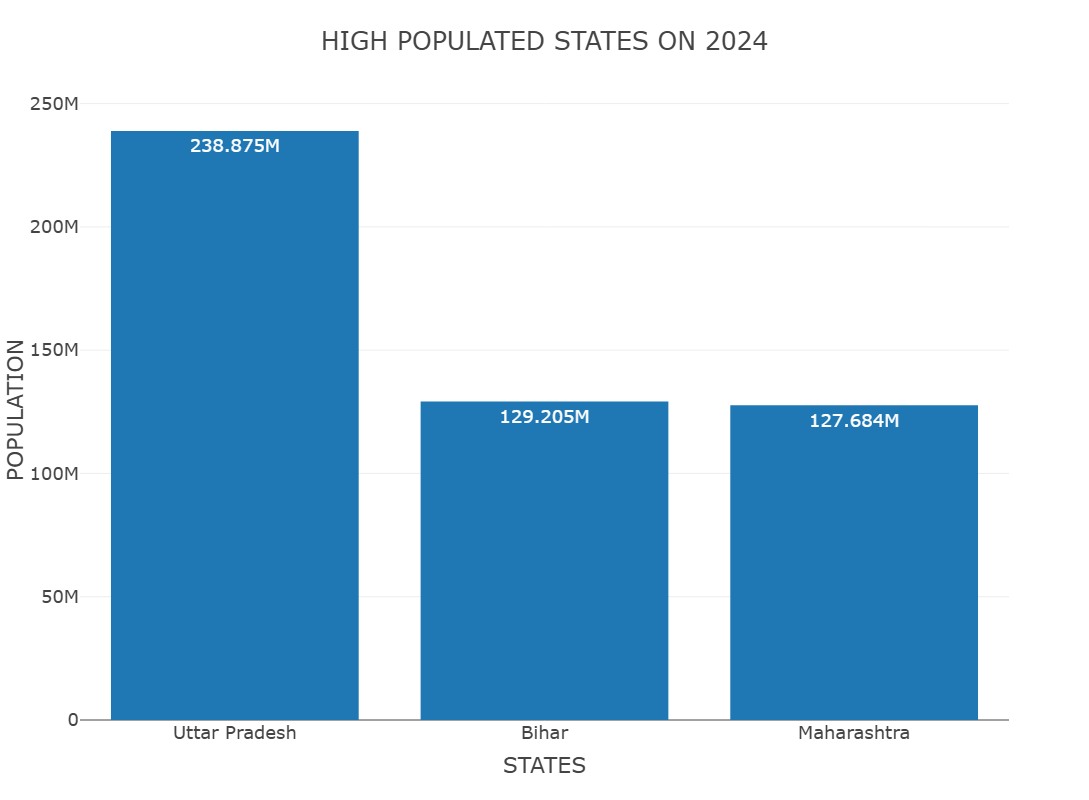

In [17]:
pop_bar = px.bar(
    top_pop.head(3),
    x="States/Uts",
    y="population(2024)",
    text_auto=True,
    title="HIGH POPULATED STATES ON 2024",
    height=800,
    labels={"States/Uts": "STATES", "population(2024)": "POPULATION"},
    template="presentation",
)

pop_bar.show(config=CHART_CONFIG)

In [18]:
top_literacy = pop.groupby(["States/Uts","average (literacy rate)"]).sum().sort_values(by="average (literacy rate)",ascending=False).reset_index()

print(top_literacy.head(3))

    States/Uts  average (literacy rate) population(1901) population(1951)  \
0       Kerala                    96.20          6396262         13549118   
1  Lakshadweep                    92.28            13882            21035   
2      Mizoram                    91.58            82434           196202   

   population(2011)  population(2023)  population(2024)  Male(literacy rate)  \
0          33406061          35824000          35967000                97.40   
1             64473             69000             69000                96.11   
2           1097206           1241000           1252000                93.72   

   Female (literacy rate)Average (literacy rate)  Area (sq. km)       GDP  \
0                                          95.20          38852  11.30000   
1                                          88.25             32   9.19697   
2                                          89.40          21081   0.36000   

   per capita in  sex ratio (number of female per male)   Hin

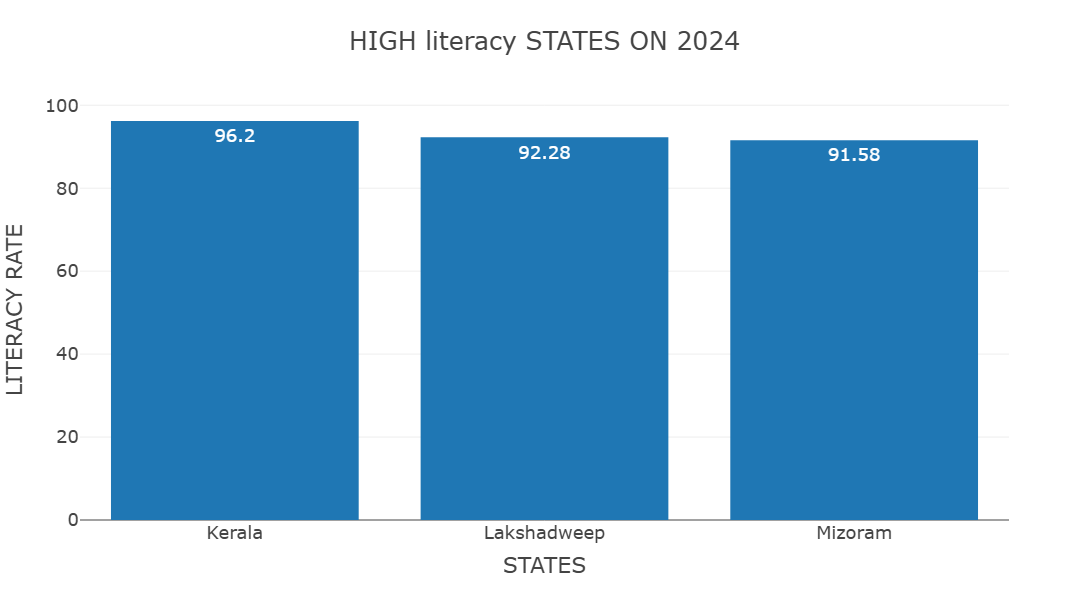

In [19]:
literacy_bar = px.bar(
    top_literacy.head(3),
    x="States/Uts",
    y="average (literacy rate)",
    text_auto=True,
    title="HIGH literacy STATES ON 2024",
    height=600,
    labels={"States/Uts": "STATES", "average (literacy rate)": "LITERACY RATE"},
    template="presentation",
)

literacy_bar.show(config=CHART_CONFIG)

## Feature Selection

In [20]:
features = ["population(2011)", "population(2023)", "population(2024)"]
for col in features:
    pop[col] = pd.to_numeric(pop[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')


In [21]:
pop[features]

,population(2011),population(2023),population(2024)
0,380581,403000,404000
1,49386799,53217000,53402000
2,1383727,1565000,1580000
3,31205576,35824000,36159000
4,104099452,127368000,129205000
5,1055450,1235000,1247000
6,25545198,30294000,30638000
7,586956,1293000,1387000
8,16787941,21490000,21884000
9,1458545,1577000,1585000


## Splitting the Dataset

In [22]:
X_train = pop[['population(2011)', 'population(2023)']]
y_train = pop['population(2024)']


## Model Selection

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-0.09, 1.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['population(2011)','population(2023)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.971e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


## Evaluation & Tuning

In [24]:
y_pred_2024 = model.predict(X_train)
print("--- Model Validation Metrics ---")
print(f"R² Score: {r2_score(y_train, y_pred_2024):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_train, y_pred_2024):,.0f}\n")

--- Model Validation Metrics ---
R² Score: 1.0000
Mean Absolute Error: 24,982



In [25]:
X_2026 = pop[['population(2023)', 'population(2024)']].rename(
    columns={'population(2023)': 'population(2011)', 'population(2024)': 'population(2023)'})


In [26]:
pop['predicted_population_2026'] = model.predict(X_2026).round().astype(int)

In [27]:
display(pop.head(5))

,States/Uts,population(1901),population(1951),population(2011),population(2023),population(2024),Male(literacy rate),Female (literacy rate)Average (literacy rate),average (literacy rate),Area (sq. km),...,per capita in,sex ratio (number of female per male),Hindu,Muslim,Christian,Sikhs,Buddhist,Others,Majority,predicted_population_2026
0,Andaman and Nicobar Islands,24649,30971,380581,403000,404000,90.11,81.84,86.27,8249,...,229000.0,1045,0.6945,0.0852,0.2128,0.0034,0.0009,0.0032,Hindu,422731
1,Andhra Pradesh,13071874,20216637,49386799,53217000,53402000,73.40,59.50,66.40,162970,...,219518.0,963,0.9087,0.0733,0.0138,0.0002,0.0001,0.0039,Hindu,53296332
2,Arunachal Pradesh,-,-,1383727,1565000,1580000,73.69,59.57,66.95,83743,...,256410.0,997,0.2904,0.0195,0.3026,0.0024,0.1177,0.2674,Christian,1596821
3,Assam,3289680,8028856,31205576,35824000,36159000,90.10,81.20,85.90,78438,...,118504.0,1012,0.6147,0.3422,0.0374,0.0007,0.0018,0.0032,Hindu,36111818
4,Bihar,27311865,29085017,104099452,127368000,129205000,79.70,60.50,70.90,94163,...,54000.0,1090,0.8269,0.1687,0.0012,0.0002,0.0002,0.0028,Hindu,129040605


## Monitoring the  Predicted Data

In [28]:
print("--- 2026 Population Predictions Sample ---")
print(pop[['States/Uts', 'population(2023)', 'population(2024)', 'predicted_population_2026']].head(10))


--- 2026 Population Predictions Sample ---
                             States/Uts  population(2023)  population(2024)  \
0           Andaman and Nicobar Islands            403000            404000   
1                        Andhra Pradesh          53217000          53402000   
2                     Arunachal Pradesh           1565000           1580000   
3                                 Assam          35824000          36159000   
4                                 Bihar         127368000         129205000   
5                            Chandigarh           1235000           1247000   
6                          Chhattisgarh          30294000          30638000   
7  Dadra & Nagar Haveli and Daman & Diu           1293000           1387000   
8                                 Delhi          21490000          21884000   
9                                   Goa           1577000           1585000   

   predicted_population_2026  
0                     422731  
1                   53296

In [29]:
top_pop.columns.tolist()

['States/Uts',
 'population(2024)',
 'population(1901)',
 'population(1951)',
 'population(2011)',
 'population(2023)',
 'Male(literacy rate)',
 'Female (literacy rate)Average (literacy rate)',
 'average (literacy rate)',
 'Area (sq. km)',
 'GDP',
 'per capita in',
 'sex ratio (number of female per male)',
 'Hindu',
 'Muslim',
 'Christian',
 'Sikhs',
 'Buddhist',
 'Others',
 'Majority']

## Visualizations Required To Plot Highly Populated Indian States Map

In [30]:
pop_2026 = pop.groupby(["States/Uts","predicted_population_2026"]).max().sort_values(by="predicted_population_2026",ascending=False).reset_index()
print(pop_2026[["States/Uts","predicted_population_2026"]].head(3))

      States/Uts  predicted_population_2026
0  Uttar Pradesh                  238468054
1          Bihar                  129040605
2    Maharashtra                  127449559


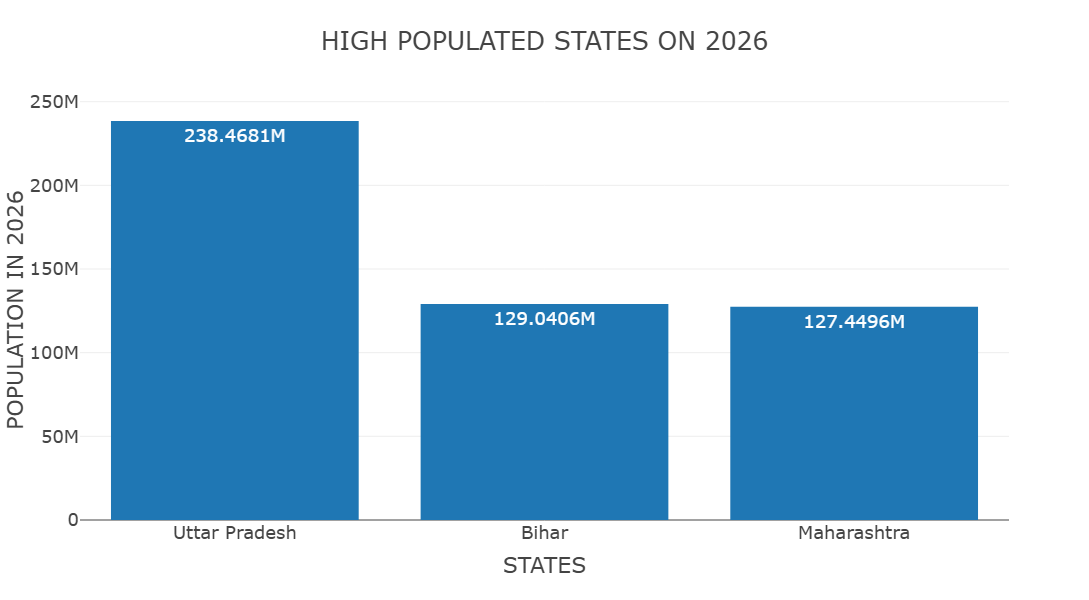

In [31]:
pop_2026_bar = px.bar(
    pop_2026.head(3),
    x="States/Uts",
    y="predicted_population_2026",
    text_auto=True,
    title="HIGH POPULATED STATES ON 2026",
    height=600,
    labels={"States/Uts": "STATES", "predicted_population_2026": "POPULATION IN 2026"},
    template="presentation",
)

pop_2026_bar.show(config=CHART_CONFIG)

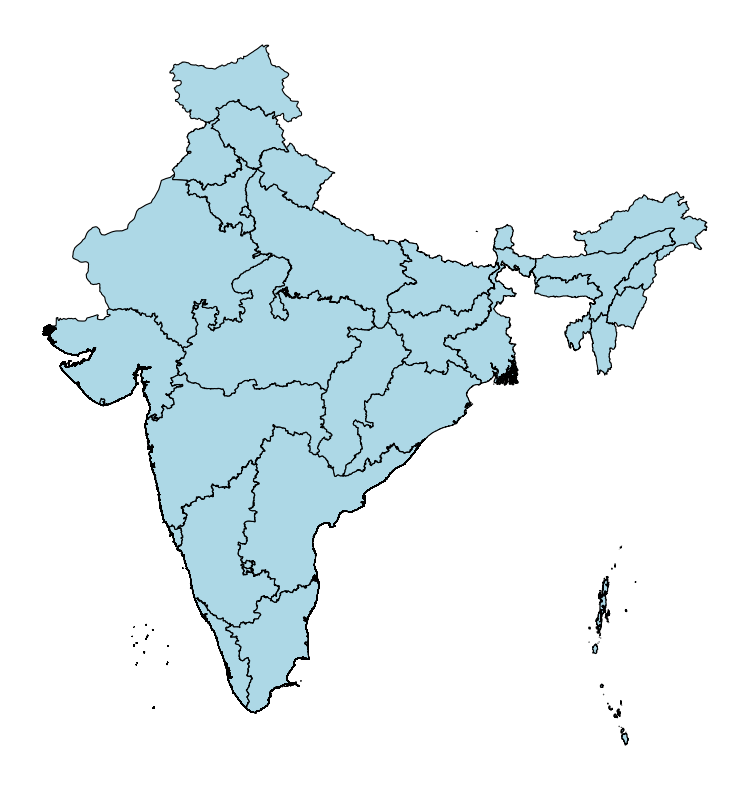

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt
india_gdf = gpd.read_file("india_state.geojson")
fig, ax = plt.subplots(figsize=(10, 10))
india_gdf.plot(ax=ax, edgecolor='black', color='lightblue', linewidth=0.8)
plt.axis('off')
plt.show()

In [33]:
india_gdf.head(3)

,ID_0,ISO,NAME_0,ID_1,NAME_1,NL_NAME_1,VARNAME_1,TYPE_1,ENGTYPE_1,geometry
0,105,IND,India,1,Andaman and Nicobar,None,Andaman & Nicobar Islands|Andaman et Nicobar|I...,Union Territor,Union Territory,"MULTIPOLYGON (((93.78773 6.85264, 93.78849 6.8..."
1,105,IND,India,2,Andhra Pradesh,None,NaN,State,State,"MULTIPOLYGON (((80.27458 13.45958, 80.27458 13..."
2,105,IND,India,3,Arunachal Pradesh,None,Agence de la Frontire du Nord-Est(French-obsol...,State,State,"POLYGON ((96.15778 29.3831, 96.1638 29.37668, ..."


In [34]:
print(india_gdf.columns)

Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'NL_NAME_1', 'VARNAME_1',
       'TYPE_1', 'ENGTYPE_1', 'geometry'],
      dtype='str')


##  Heat Map For Most Populated States of India (2026)

In [35]:
india_gdf.columns = india_gdf.columns.to_flat_index()
pop_dict=pop.set_index("States/Uts")["predicted_population_2026"]
india_gdf["pop_2026"]=india_gdf["NAME_1"].map(pop_dict).fillna(0)
india_gdf["STATE_NAME"] = india_gdf["NAME_1"].str.strip().str.title()


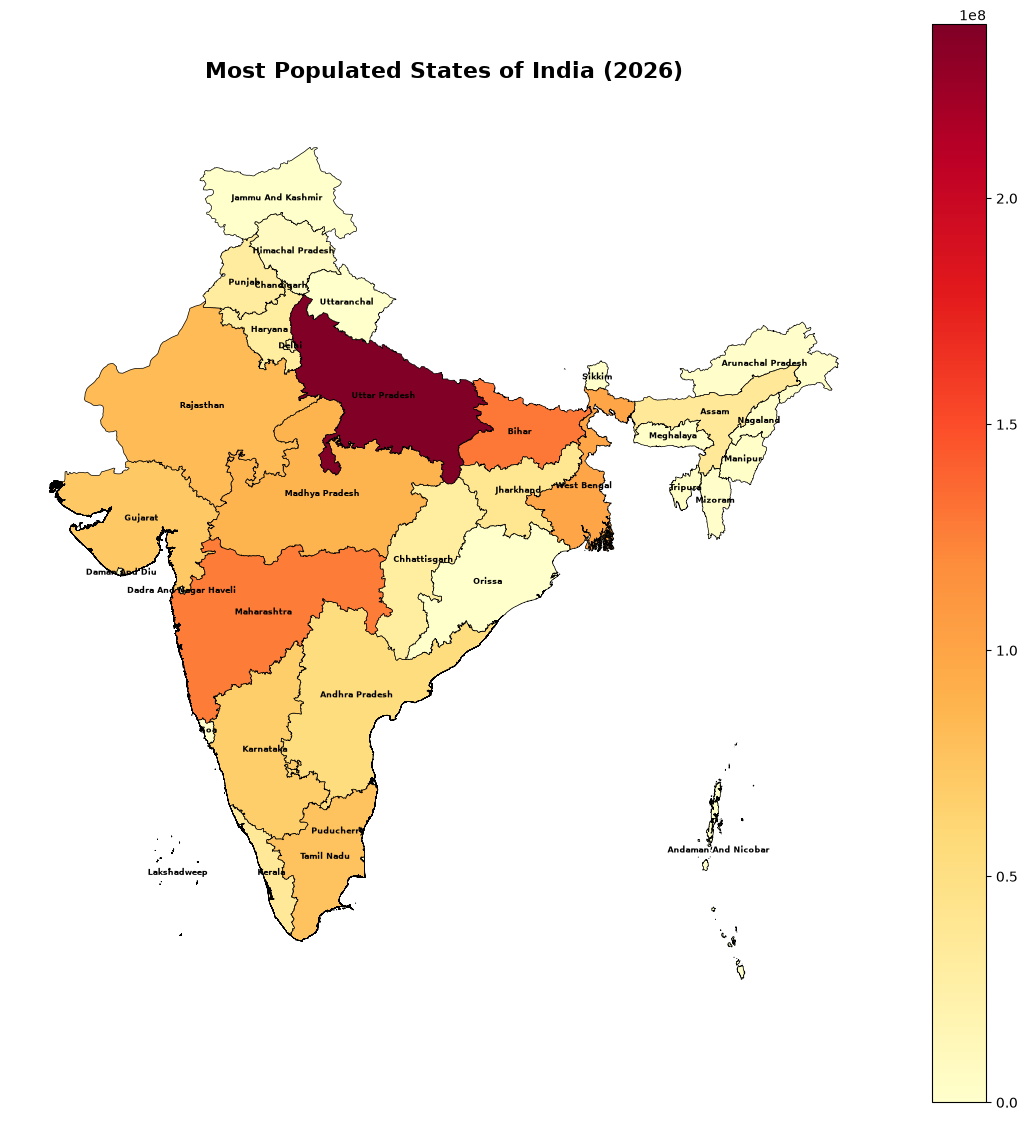

In [36]:
fig, ax = plt.subplots(figsize=(14, 14))
india_gdf.plot(
    column="pop_2026",
    ax=ax, 
    legend=True,
    edgecolor='black', 
    cmap="YlOrRd",
    linewidth=0.5)
for idx, row in india_gdf.iterrows():
    centroid = row['geometry'].centroid
    state_name = row['STATE_NAME']
    ax.text(
        x=centroid.x, 
        y=centroid.y, 
        s=state_name, 
        fontsize=6,     
        ha='center',        
        va='center',        
        color='black',       
        weight='bold'   
    )
plt.title(
    "Most Populated States of India (2026)", 
    fontsize=16, 
    fontweight='bold', 
    pad=20,          
    loc='center'     
)

plt.axis('off')
plt.show()